In [1]:
from statsbombpy import sb

# List all free competitions
competitions = sb.competitions()
print(competitions[['competition_name','season_name']].head(20))

d:\Nimmi\repos\fdna\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


          competition_name season_name
0            1. Bundesliga   2023/2024
1            1. Bundesliga   2015/2016
2   African Cup of Nations        2023
3         Champions League   2018/2019
4         Champions League   2017/2018
5         Champions League   2016/2017
6         Champions League   2015/2016
7         Champions League   2014/2015
8         Champions League   2013/2014
9         Champions League   2012/2013
10        Champions League   2011/2012
11        Champions League   2010/2011
12        Champions League   2009/2010
13        Champions League   2008/2009
14        Champions League   2006/2007
15        Champions League   2004/2005
16        Champions League   2003/2004
17        Champions League   1999/2000
18        Champions League   1972/1973
19        Champions League   1971/1972


In [2]:
# La Liga 2015/16 = competition_id 11, season_id 26
matches = sb.matches(competition_id=11, season_id=26)
print(f"Matches loaded: {len(matches)}")
print(matches[['home_team','away_team','match_date']].head())

d:\Nimmi\repos\fdna\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Matches loaded: 38
   home_team    away_team  match_date
0  Barcelona  Real Madrid  2015-03-22
1  Barcelona      Sevilla  2014-11-22
2     Málaga    Barcelona  2014-09-24
3  Barcelona       Getafe  2015-04-28
4  Barcelona      Granada  2014-09-27


In [3]:
# Get the first match ID
match_id = matches.iloc[0]['match_id']

# Load all events for that match
events = sb.events(match_id=match_id)
print(events.shape)           # rows x columns
print(events['type'].unique()) # all event types in this match
print(events.columns.tolist()) # all available fields


d:\Nimmi\repos\fdna\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


(3823, 92)
<ArrowStringArray>
[   'Starting XI',     'Half Start',           'Pass',  'Ball Receipt*',
          'Carry',       'Pressure',   'Interception',     'Miscontrol',
  'Ball Recovery',   'Dispossessed',           'Duel',          'Block',
      'Clearance',  'Dribbled Past',        'Dribble',         'Shield',
           'Shot',    'Goal Keeper', 'Foul Committed',       'Foul Won',
          '50/50',  'Bad Behaviour',       'Half End',   'Substitution',
 'Tactical Shift']
Length: 25, dtype: str
['50_50', 'bad_behaviour_card', 'ball_receipt_outcome', 'ball_recovery_offensive', 'ball_recovery_recovery_failure', 'block_deflection', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 'dribble_no_touch', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_offensive', 'foul_c

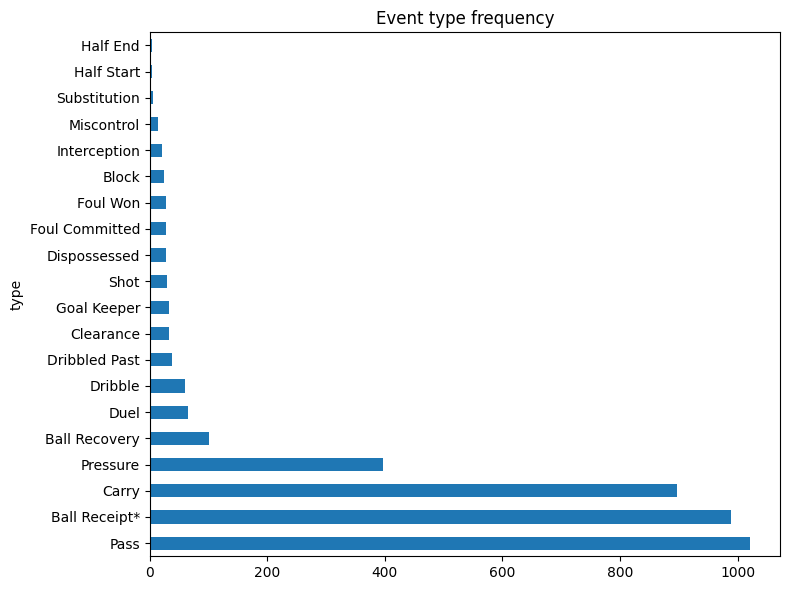

In [5]:
import matplotlib.pyplot as plt

events['type'].value_counts().head(20).plot(kind='barh', figsize=(8,6))
plt.title('Event type frequency')
plt.tight_layout()
plt.show()